# Patch & Model

Patch counts: {'up': 21, 'dn': 21}
mu used for contour (up/dn): 0.0 0.0
gauge method (up/dn): manual_exact_M_hex_parallel_transport_21_dropDupM_gaugeFixed manual_exact_M_hex_parallel_transport_21_dropDupM_gaugeFixed
gauge loop phase (up/dn): -1.2246467991473532e-16 -1.2246467991473532e-16

===== exact M6 anchors in centered 1BZ =====
M0: k=[-1.570796 -0.9069  ] | k_can=[1.570796 0.9069  ]
M1: k=[ 0.       -1.813799] | k_can=[0.       1.813799]
M2: k=[ 1.570796 -0.9069  ] | k_can=[1.570796 2.720699]
M3: k=[1.570796 0.9069  ] | k_can=[1.570796 0.9069  ]
M4: k=[0.       1.813799] | k_can=[0.       1.813799]
M5: k=[-1.570796  0.9069  ] | k_can=[1.570796 2.720699]

===== kept indices in full loop =====
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 17, 18, 19, 21, 22, 23]

===== up exact-M21 patches =====
id= 0 | k=[-1.570796 -0.9069  ] | k_can=[1.570796 0.9069  ] | E=1.0947644253e-47 | |vF|=7.747470e-16 | w=[0. 1. 0.]
id= 1 | k=[-1.178097 -1.133625] | k_can=[1.963495 4.307773] | E=1.52

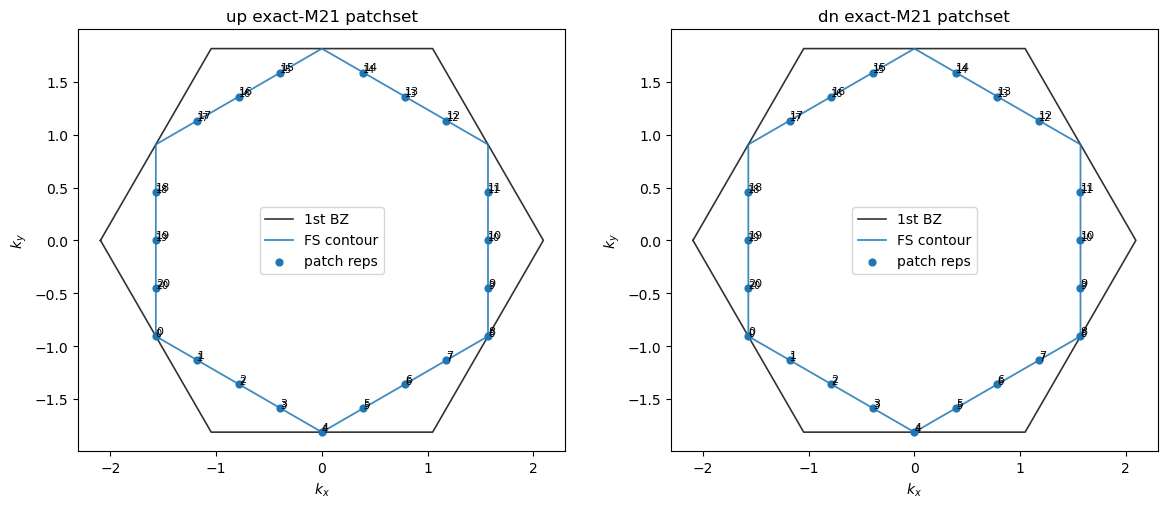

In [5]:
# ============================================================
# Required definitions BEFORE the manual exact-M patch cell
# ============================================================

# Example model params:
MODEL_PARAMS = {"t": 1.0, "phi": np.pi/4}
# If you already defined MODEL_PARAMS elsewhere, keep your own value.

model = KagomeNagaosa(MODEL_PARAMS, spin=True, B=None)

# Spinful KagomeNagaosa has 6 orbitals total:
#   up sector = first 3
#   dn sector = last 3
UP_SLICE = slice(0, 3)
DN_SLICE = slice(3, 6)

# IMPORTANT:
# choose the band index within EACH 3x3 spin block.
# If your previous notebook already had the correct value, use that.
# For many kagome runs the local band index is often 1, but change it if needed.
LOCAL_BAND_INDEX = 1
import numpy as np
import matplotlib.pyplot as plt
from patching import PatchPoint, PatchSet, plot_patchset

model = KagomeNagaosa(dict(t=1.0, phi=0.0), spin=True, B=None)

# ------------------------------------------------------------
# choose patch density / options here
# ------------------------------------------------------------
POINTS_PER_EDGE = 4           # 1->6, 2->12, 4->24
REMOVE_DUPLICATE_M_MODG = True # True: remove replicated M anchors modulo G
GAUGE_FIX = True
CLOSE_LOOP_GAUGE = True
GAUGE_ANCHOR = "max_component"  # or "first_component"

patchsets = {
    "up": build_exactM_patchset(
        model,
        UP_SLICE,
        LOCAL_BAND_INDEX,
        points_per_edge=POINTS_PER_EDGE,
        remove_duplicate_M_modG=REMOVE_DUPLICATE_M_MODG,
        gauge_fix=GAUGE_FIX,
        close_loop_gauge=CLOSE_LOOP_GAUGE,
        gauge_anchor=GAUGE_ANCHOR,
    ),
    "dn": build_exactM_patchset(
        model,
        DN_SLICE,
        LOCAL_BAND_INDEX,
        points_per_edge=POINTS_PER_EDGE,
        remove_duplicate_M_modG=REMOVE_DUPLICATE_M_MODG,
        gauge_fix=GAUGE_FIX,
        close_loop_gauge=CLOSE_LOOP_GAUGE,
        gauge_anchor=GAUGE_ANCHOR,
    ),
}

NPATCH = patchsets["up"].Npatch
PATCHSETS = patchsets

# ------------------------------------------------------------
# print info
# ------------------------------------------------------------
print("Patch counts:", {k: v.Npatch for k, v in patchsets.items()})
print("mu used for contour (up/dn):", patchsets["up"].mu_used_for_contour, patchsets["dn"].mu_used_for_contour)
print("gauge method (up/dn):", patchsets["up"].gauge_method, patchsets["dn"].gauge_method)
print("gauge loop phase (up/dn):", patchsets["up"].gauge_loop_phase, patchsets["dn"].gauge_loop_phase)

print("\n===== exact M6 anchors in centered 1BZ =====")
M6 = exact_M6_points_1bz(model)
for i, k in enumerate(M6):
    print(
        f"M{i}: k={np.round(k, 6)} | "
        f"k_can={np.round(_canonicalize_k_mod_G(model, k), 6)}"
    )

if REMOVE_DUPLICATE_M_MODG:
    keep_idx = _patch_keep_indices_remove_duplicate_M_anchors(model, POINTS_PER_EDGE)
    print("\n===== kept indices in full loop =====")
    print(keep_idx.tolist())

for spin in ["up", "dn"]:
    print(f"\n===== {spin} exact-M{NPATCH} patches =====")
    for p in patchsets[spin].patches:
        print(
            f"id={p.patch_id:2d} | "
            f"k={np.round(p.k_cart, 6)} | "
            f"k_can={np.round(_canonicalize_k_mod_G(model, p.k_cart), 6)} | "
            f"E={p.energy:.10e} | "
            f"|vF|={p.vF_norm:.6e} | "
            f"w={np.round(p.orbital_weight, 6)}"
        )

# ------------------------------------------------------------
# neighbor distance sanity check (patch reps only)
# ------------------------------------------------------------
for spin in ["up", "dn"]:
    ks = np.array([p.k_cart for p in patchsets[spin].patches], dtype=float)
    d = np.linalg.norm(np.roll(ks, -1, axis=0) - ks, axis=1)
    print(f"\n===== {spin} neighbor distances (patch reps only) =====")
    print(np.round(d, 8))

# ------------------------------------------------------------
# optional overlap sanity check for gauge smoothness
# ------------------------------------------------------------
for spin in ["up", "dn"]:
    U = np.array([p.eigvec for p in patchsets[spin].patches], dtype=complex)
    ovs = []
    for i in range(len(U)):
        j = (i + 1) % len(U)
        ovs.append(np.vdot(U[i], U[j]))
    ovs = np.asarray(ovs, dtype=complex)

    print(f"\n===== {spin} neighbor overlaps after gauge fixing =====")
    print("abs  =", np.round(np.abs(ovs), 8))
    print("arg  =", np.round(np.angle(ovs), 8))

# ------------------------------------------------------------
# plot
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, spin in zip(axes, ["up", "dn"]):
    plot_patchset(
        patchsets[spin],
        ax=ax,
        show_contour=True,   # contour remains the original full loop
        show_velocity=False,
        show_bz=True,
    )

    ks = np.array([p.k_cart for p in patchsets[spin].patches], dtype=float)
    for i, k in enumerate(ks):
        ax.text(k[0], k[1], str(i), fontsize=8, ha="left", va="bottom")

    ax.set_title(f"{spin} exact-M{NPATCH} patchset")

plt.tight_layout()
plt.show()

# Model

In [7]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from importlib import reload

import noninteracting
import interaction
import frg_kernel
import frg_flow
import channels

reload(noninteracting)
reload(interaction)
reload(frg_kernel)
reload(frg_flow)
reload(channels)

from interaction import BareExtendedHubbard
from frg_flow import FRGFlowSolverSZ0, BareSZ0VertexFromInteraction
from channels import SZ0ChannelBuilder

# ------------------------------------------------------------
# choose interaction case
# ------------------------------------------------------------
CASE = "V_only"   # "V_only" or "U_only"

if CASE == "V_only":
    U_TEST, V_TEST = 5.0, 8.0
elif CASE == "U_only":
    U_TEST, V_TEST = 8.0, 0.0
else:
    raise ValueError("CASE must be 'V_only' or 'U_only'")

# ------------------------------------------------------------
# flow params
# ------------------------------------------------------------
T_START = 30
T_STOP  = 0.1
NFREQ   = 40
NSTEPS  = 300

# choose which Q to inspect
# Q_CHOICE = np.array([0.0, 0.0])  # Q=0
M6 = exact_M6_points_1bz(model)
Q_CHOICE = np.array(M6[0], dtype=float)   # M1

print("CASE =", CASE, " | U =", U_TEST, " V =", V_TEST)
print("T_START, T_STOP, NFREQ, NSTEPS =", T_START, T_STOP, NFREQ, NSTEPS)
print("Q_CHOICE =", np.round(Q_CHOICE, 8))
print("NPATCH =", PATCHSETS["up"].Npatch)


# ------------------------------------------------------------
# build bare interaction from the SAME model you used for patchsets
# ------------------------------------------------------------
bare_int = BareExtendedHubbard.from_kagome_model(model, U=U_TEST, V=V_TEST)

# minimal S_z=0 bare vertex adapter
bare_sz0 = BareSZ0VertexFromInteraction(bare_int, PATCHSETS)

solver = FRGFlowSolverSZ0(
    patchsets=PATCHSETS,
    bare_vertex=bare_sz0,
    T_start=T_START,
    T_stop=T_STOP,
    n_steps=NSTEPS,
    temperature_grid="linear",
    nfreq=NFREQ,
    include_explicit_T_prefactor=True,
    max_relative_update=20,
    min_substep_fraction=1.0/512.0,
    channel_divergence_threshold=1e6,
)

print("solver built.")
print("temperature path length =", len(solver.temperature_path))
print("initial channel norm =", solver.state.channel_norm())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
CASE = V_only  | U = 5.0  V = 8.0
T_START, T_STOP, NFREQ, NSTEPS = 30 0.1 40 300
Q_CHOICE = [-1.57079633 -0.90689968]
NPATCH = 21
solver built.
temperature path length = 300
initial channel norm = 16.000000000000004


# Flow

start debug flow ...
initial T = 30.0
n_steps   = 300
Npatch    = 21
[step 000] T=30.000000 | rhs=0.000e+00 | best=pp_singlet@((1.570796, 2.720699)) | |eig0|=1.280e+02 | ppS=1.280e+02 ppT=7.794e+01 phC=1.080e+02 phS=6.795e+01 | sub=0 rel=0.000e+00
[step 001] T=29.900000 | rhs=1.787e+00 | best=pp_singlet@((1.570796, 2.720699)) | |eig0|=1.280e+02 | ppS=1.280e+02 ppT=7.766e+01 phC=1.082e+02 phS=6.780e+01 | sub=1 rel=1.117e-02
[step 002] T=29.800000 | rhs=1.760e+00 | best=pp_singlet@((1.570796, 2.720699)) | |eig0|=1.280e+02 | ppS=1.280e+02 ppT=7.738e+01 phC=1.084e+02 phS=6.765e+01 | sub=1 rel=1.100e-02
[step 003] T=29.700000 | rhs=1.735e+00 | best=pp_singlet@((1.570796, 0.906900)) | |eig0|=1.281e+02 | ppS=1.281e+02 ppT=7.711e+01 phC=1.086e+02 phS=6.751e+01 | sub=1 rel=1.084e-02
[step 004] T=29.600000 | rhs=1.710e+00 | best=pp_singlet@((1.570796, 2.720699)) | |eig0|=1.281e+02 | ppS=1.281e+02 ppT=7.684e+01 phC=1.087e+02 phS=6.737e+01 | sub=1 rel=1.069e-02
[step 005] T=29.500000 | rhs=1.686e+

,step,T,rhs_norm,accepted_substeps,max_rel_update,overall_channel,overall_abs_eig0,overall_Qx,overall_Qy,pp_singlet_abs_eig0,pp_triplet_abs_eig0,ph_charge_abs_eig0,ph_spin_abs_eig0,stop_reason
157,157,14.3,1.376728e+02,1,0.161121,pp_singlet,1.244784e+03,1.570796,0.9069,1.244784e+03,1.178464e+02,9.317409e+02,2.404675e+02,
158,158,14.2,1.803591e+02,1,0.181788,pp_singlet,1.436148e+03,1.570796,0.9069,1.436148e+03,1.322132e+02,1.039088e+03,2.782486e+02,
159,159,14.1,2.445472e+02,1,0.208569,pp_singlet,1.694481e+03,1.570796,0.9069,1.694481e+03,1.506965e+02,1.175228e+03,3.288473e+02,
160,160,14.0,3.464447e+02,1,0.244483,pp_singlet,2.059129e+03,1.570796,0.9069,2.059129e+03,1.752819e+02,1.353176e+03,3.995868e+02,
161,161,13.9,5.198983e+02,1,0.294812,pp_singlet,2.604977e+03,1.570796,0.9069,2.604977e+03,2.094399e+02,1.595004e+03,5.042323e+02,
162,162,13.8,8.438565e+02,1,0.369563,pp_singlet,3.490207e+03,1.570796,0.9069,3.490207e+03,2.597954e+02,1.941225e+03,6.714405e+02,
163,163,13.7,1.531760e+03,1,0.489811,pp_singlet,5.099672e+03,1.570796,0.9069,5.099672e+03,3.674204e+02,2.474798e+03,9.697391e+02,
164,164,13.6,3.292679e+03,1,0.706734,pp_singlet,8.577567e+03,1.570796,0.9069,8.577567e+03,6.084328e+02,3.395211e+03,1.598756e+03,
165,165,13.5,9.323981e+03,1,1.172579,pp_singlet,1.852913e+04,1.570796,0.9069,1.852913e+04,1.261869e+03,5.325509e+03,3.342930e+03,
166,166,13.4,4.323842e+04,1,2.502851,pp_singlet,6.546916e+04,1.570796,0.9069,6.546916e+04,4.119802e+03,1.143602e+04,1.125731e+04,


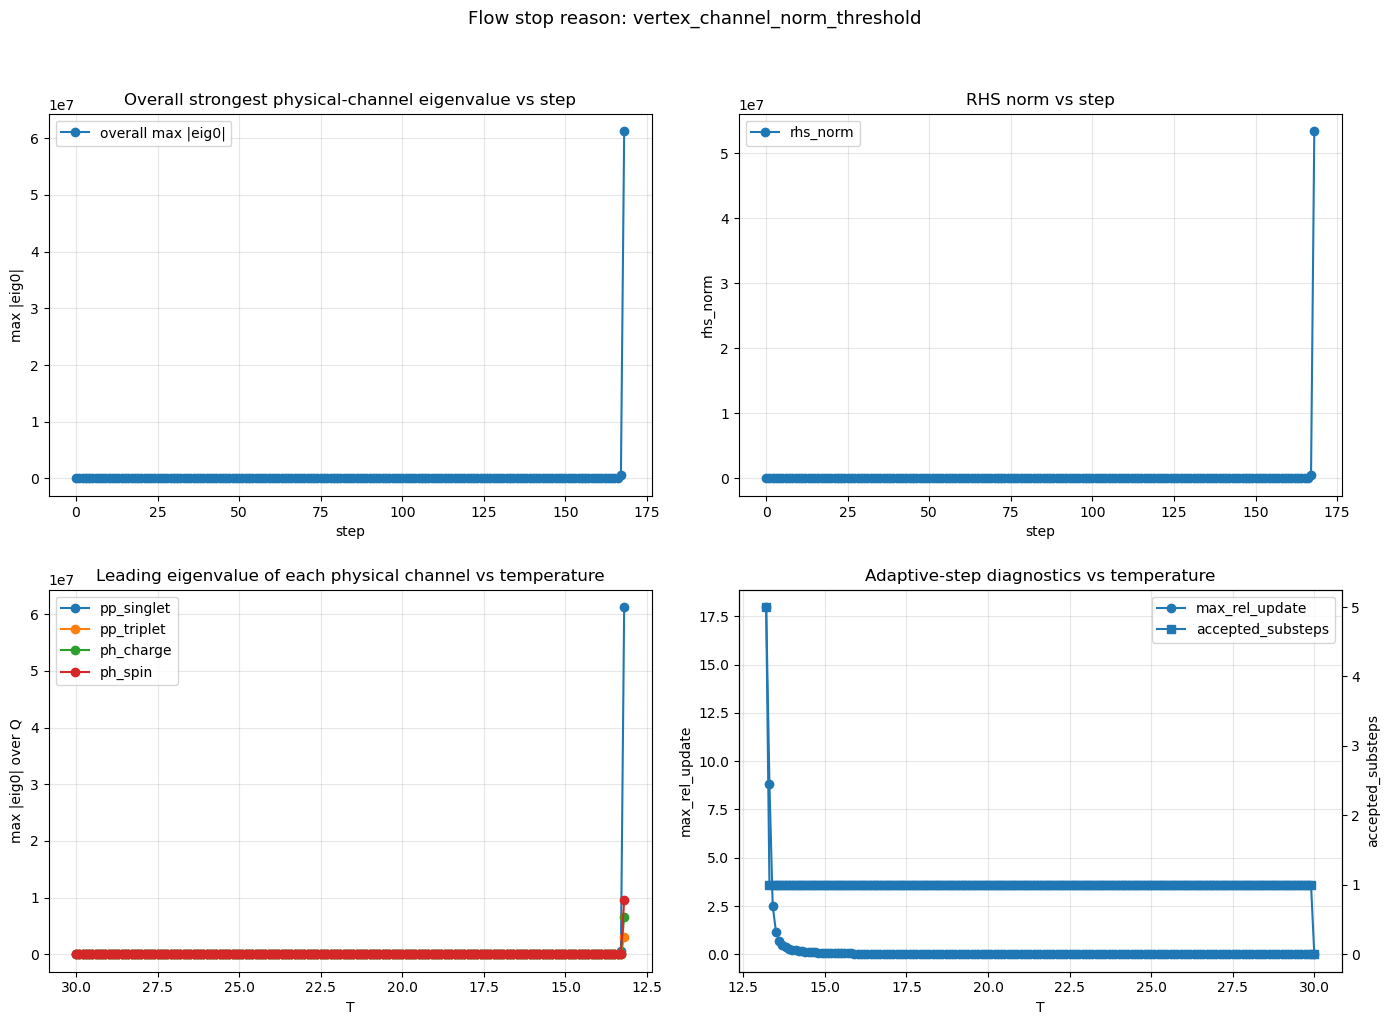

In [8]:
# ============================================================
# Debug flow run on the already-built solver
# NOTE:
#   1. this mutates solver.state
#   2. rerun your solver-construction cell before each new run
# ============================================================

EIG_THRESHOLD = None      # e.g. 5e2 ; None means do not stop by physical-channel eigenvalue
SORT_BY = "abs"           # "abs", "real", "hermitian"
VERBOSE_EVERY = 1

print("start debug flow ...")
print("initial T =", solver.state.T)
print("n_steps   =", len(solver.temperature_path))
print("Npatch    =", solver.Npatch)

debug_df, debug_summary = run_debug_flow_with_channel_scan(
    solver,
    sort_by=SORT_BY,
    eigenvalue_threshold=EIG_THRESHOLD,
    verbose_every=VERBOSE_EVERY,
)

print_run_summary(debug_df, debug_summary)
show_debug_summary(debug_df, tail=min(12, len(debug_df)))
plot_debug_flow_df(debug_df, debug_summary)

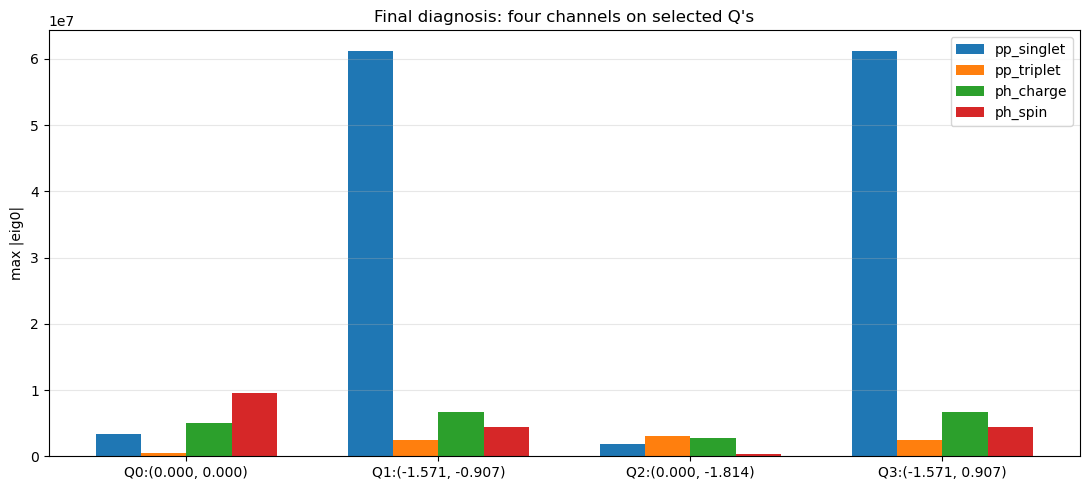

In [12]:
from channels import SZ0ChannelBuilder

diagnosis_Qs = [np.array([0,0]), M6[0], M6[1], M6[-1]]

SORT_BY = "abs"     # "abs", "real", "hermitian"
DEG_TOL = 1e-8      # 判断“最大本征值简并”的容差
VEC_PRINT_CUTOFF = 1e-6  # 打印本征态时，小于这个幅值的分量忽略
NORMALIZE_EIGVEC_PHASE = True

# -------------------------------
# build channel builder
# -------------------------------
builder = build_sz0_builder_from_solver(solver)

channel_map = {
    "pp_singlet": builder.pp_singlet,
    "pp_triplet": builder.pp_triplet,
    "ph_charge": builder.ph_charge,
    "ph_spin": builder.ph_spin,
}

records = []
full_results = {}

for ch_name, ch_fn in channel_map.items():
    full_results[ch_name] = {}
    for iq, Q in enumerate(diagnosis_Qs):
        ker = ch_fn(np.asarray(Q, dtype=float))
        summ = summarize_kernel(ker, sort_by=SORT_BY, deg_tol=DEG_TOL)

        records.append({
            "channel": ch_name,
            "Q_index": iq,
            "Qx": float(Q[0]),
            "Qy": float(Q[1]),
            "lead_abs": summ["lead_abs"],
            "lead_real": summ["lead_real"],
            "lead_deg": summ["lead_deg"],
        })
        full_results[ch_name][iq] = {
            "Q": np.asarray(Q, dtype=float),
            **summ,
        }

df_diag = pd.DataFrame(records)

# -------------------------------
# bar chart
# -------------------------------
q_labels = q_label_from_list(diagnosis_Qs)
channels_order = ["pp_singlet", "pp_triplet", "ph_charge", "ph_spin"]

x = np.arange(len(diagnosis_Qs))
width = 0.18

fig, ax = plt.subplots(figsize=(11, 5))

for j, ch in enumerate(channels_order):
    sub = df_diag[df_diag["channel"] == ch].sort_values("Q_index")
    ax.bar(
        x + (j - 1.5) * width,
        sub["lead_abs"].values,
        width=width,
        label=ch,
    )

ax.set_xticks(x)
ax.set_xticklabels(q_labels, rotation=0)
ax.set_ylabel("max |eig0|")
ax.set_title("Final diagnosis: four channels on selected Q's")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------
# table display
# -------------------------------
# display(df_diag.sort_values(["Q_index", "channel"]).reset_index(drop=True))
#
# # -------------------------------
# # print detailed info
# # -------------------------------
# print("\n" + "=" * 90)
# print("Detailed leading-eigenvalue diagnosis")
# print("=" * 90)
#
# for iq, Q in enumerate(diagnosis_Qs):
#     print(f"\n########################  Q[{iq}] = {fmt_q(Q)}  ########################")
#     for ch in channels_order:
#         info = full_results[ch][iq]
#         print(f"\n--- {ch} ---")
#         print(f"max |eig0|     = {info['lead_abs']:.12e}")
#         print(f"lead eig0      = {info['lead_val']}")
#         print(f"degeneracy     = {info['lead_deg']}")
#
#         for ideg, vec in enumerate(info["lead_vecs"]):
#             print(f"  leading eigenvector #{ideg + 1}:")
#             print(pretty_print_eigvec(vec, cutoff=VEC_PRINT_CUTOFF))
# #
# # -------------------------------
# # strongest Q for each channel
# # -------------------------------
# print("\n" + "=" * 90)
# print("Strongest Q for each channel")
# print("=" * 90)
#
# for ch in channels_order:
#     sub = df_diag[df_diag["channel"] == ch].sort_values("lead_abs", ascending=False).iloc[0]
#     print(
#         f"{ch:12s} : max |eig0| = {sub['lead_abs']:.12e} "
#         f"at Q = ({sub['Qx']:.6f}, {sub['Qy']:.6f}), "
#         f"degeneracy = {int(sub['lead_deg'])}"
#     )

# Debug

# Helper

In [1]:
import sys
from pathlib import Path
from pprint import pprint

import numpy as np
import matplotlib.pyplot as plt

# Make sure uploaded modules are importable
sys.path.insert(0, "/mnt/data")

from noninteracting import KagomeNagaosa
from interaction import BareExtendedHubbard
from frg_flow import BareSZ0VertexFromInteraction, FRGFlowSolverSZ0
from channels import SZ0ChannelBuilder

# patching utilities for your manual exact-M patch cell
from patching import PatchPoint, PatchSet, plot_patchset

In [2]:


# -------------------------------
# helper functions
# -------------------------------
def fmt_q(q, nd=6):
    q = np.asarray(q, dtype=float)
    return f"({q[0]:.{nd}f}, {q[1]:.{nd}f})"

def q_label_from_list(q_list):
    labels = []
    for i, q in enumerate(q_list):
        labels.append(f"Q{i}:{fmt_q(q, nd=3)}")
    return labels

def build_sz0_builder_from_solver(solver):
    return SZ0ChannelBuilder(
        vertex=solver.current_vertex_accessor(),
        patchsets=solver.patchsets,
        closure_map=solver.closure_map(),
        transfer_context=solver.transfer_context(),
        q_merge_tol_red=getattr(solver, "q_merge_tol_red", 5e-2),
        q_key_decimals=getattr(solver, "q_key_decimals", 10),
    )

def sort_eigensystem(vals, vecs, mode="abs"):
    vals = np.asarray(vals)
    vecs = np.asarray(vecs)
    if mode == "abs":
        order = np.argsort(-np.abs(vals))
    elif mode == "real":
        order = np.argsort(-np.real(vals))
    elif mode == "hermitian":
        order = np.argsort(-np.real(vals))
    else:
        raise ValueError("mode must be 'abs', 'real', or 'hermitian'")
    return vals[order], vecs[:, order]

def canonicalize_eigvec_phase(vec):
    vec = np.asarray(vec, dtype=complex).copy()
    idx = np.argmax(np.abs(vec))
    if np.abs(vec[idx]) < 1e-15:
        return vec
    phase = np.angle(vec[idx])
    vec *= np.exp(-1j * phase)
    return vec

def degeneracy_of_leading(vals, tol=1e-8):
    vals = np.asarray(vals)
    if len(vals) == 0:
        return 0
    target = np.abs(vals[0])
    return int(np.sum(np.abs(np.abs(vals) - target) < tol))

def summarize_kernel(kernel, sort_by="abs", deg_tol=1e-8):
    # 这里直接用 numpy eig，避免依赖 kernel.eig 返回格式的细节
    vals, vecs = np.linalg.eig(np.asarray(kernel.matrix, dtype=complex))
    vals, vecs = sort_eigensystem(vals, vecs, mode=sort_by)

    lead_val = vals[0] if len(vals) > 0 else 0.0 + 0.0j
    lead_deg = degeneracy_of_leading(vals, tol=deg_tol)

    lead_vecs = []
    if len(vals) > 0:
        target = np.abs(vals[0])
        for j in range(len(vals)):
            if np.abs(np.abs(vals[j]) - target) < deg_tol:
                v = vecs[:, j]
                if NORMALIZE_EIGVEC_PHASE:
                    v = canonicalize_eigvec_phase(v)
                lead_vecs.append(v)

    return {
        "vals": vals,
        "vecs": vecs,
        "lead_val": lead_val,
        "lead_abs": float(np.abs(lead_val)),
        "lead_real": float(np.real(lead_val)),
        "lead_deg": lead_deg,
        "lead_vecs": lead_vecs,
        "matrix": np.asarray(kernel.matrix, dtype=complex),
    }

def pretty_print_eigvec(vec, cutoff=1e-6):
    vec = np.asarray(vec, dtype=complex)
    lines = []
    for i, x in enumerate(vec):
        if np.abs(x) >= cutoff:
            lines.append(
                f"    [{i:02d}]  amp={np.abs(x):.6e}  "
                f"real={np.real(x): .6e}  imag={np.imag(x): .6e}"
            )
    if not lines:
        lines = ["    (all components below cutoff)"]
    return "\n".join(lines)



In [3]:
# ============================================================
# Helper functions for debug flow of minimal-Sz0 solver
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from channels import SZ0ChannelBuilder


def _fmt_q(q, nd=6):
    q = np.asarray(q, dtype=float)
    return f"({q[0]:.{nd}f}, {q[1]:.{nd}f})"


def build_channel_builder_from_solver(solver):
    return SZ0ChannelBuilder(
        vertex=solver.current_vertex_accessor(),
        patchsets=solver.patchsets,
        closure_map=solver.closure_map(),
        transfer_context=solver.transfer_context(),
        q_merge_tol_red=getattr(solver, "q_merge_tol_red", 5e-2),
        q_key_decimals=getattr(solver, "q_key_decimals", 10),
    )


def kernel_summary(kernel, sort_by="abs"):
    vals, _ = kernel.eig(sort_by=sort_by)
    eig0 = complex(vals[0]) if len(vals) > 0 else 0.0 + 0.0j
    return {
        "eig0": eig0,
        "abs_eig0": float(np.abs(eig0)),
        "real_eig0": float(np.real(eig0)),
        "fro_norm": float(np.linalg.norm(kernel.matrix)),
        "herm_res": float(kernel.hermitian_residual()),
    }


def diagnose_all_channels(
    solver,
    *,
    sort_by="abs",
    pp_Qs=None,
    ph_Qs=None,
):
    builder = build_channel_builder_from_solver(solver)

    if pp_Qs is None:
        pp_Qs = [np.asarray(q, dtype=float) for q in solver.pp_grid.q_list]
    if ph_Qs is None:
        ph_Qs = [np.asarray(q, dtype=float) for q in solver.phd_grid.q_list]

    channel_specs = {
        "pp_singlet": (builder.pp_singlet, pp_Qs),
        "pp_triplet": (builder.pp_triplet, pp_Qs),
        "ph_charge": (builder.ph_charge, ph_Qs),
        "ph_spin": (builder.ph_spin, ph_Qs),
    }

    out = {}
    overall_best = {
        "channel": None,
        "Q": None,
        "abs_eig0": -np.inf,
        "real_eig0": None,
        "fro_norm": None,
        "herm_res": None,
    }

    for ch_name, (fn, q_list) in channel_specs.items():
        best = {
            "Q": None,
            "abs_eig0": -np.inf,
            "real_eig0": None,
            "fro_norm": None,
            "herm_res": None,
        }

        for q in q_list:
            ker = fn(q)
            s = kernel_summary(ker, sort_by=sort_by)

            if s["abs_eig0"] > best["abs_eig0"]:
                best = {
                    "Q": np.asarray(q, dtype=float),
                    "abs_eig0": s["abs_eig0"],
                    "real_eig0": s["real_eig0"],
                    "fro_norm": s["fro_norm"],
                    "herm_res": s["herm_res"],
                }

            if s["abs_eig0"] > overall_best["abs_eig0"]:
                overall_best = {
                    "channel": ch_name,
                    "Q": np.asarray(q, dtype=float),
                    "abs_eig0": s["abs_eig0"],
                    "real_eig0": s["real_eig0"],
                    "fro_norm": s["fro_norm"],
                    "herm_res": s["herm_res"],
                }

        out[ch_name] = best

    out["overall_best"] = overall_best
    return out


def flatten_diag_record(step_idx, T, rec, diag):
    row = {
        "step": int(step_idx),
        "T": float(T),
        "rhs_norm": float(rec["rhs_norm"]),
        "accepted_substeps": int(rec["accepted_substeps"]),
        "max_rel_update": float(rec["max_rel_update"]),
        "stop_reason": rec.get("stop_reason", ""),
        "overall_channel": diag["overall_best"]["channel"],
        "overall_abs_eig0": float(diag["overall_best"]["abs_eig0"]),
        "overall_real_eig0": float(diag["overall_best"]["real_eig0"]),
        "overall_Qx": float(diag["overall_best"]["Q"][0]),
        "overall_Qy": float(diag["overall_best"]["Q"][1]),
    }

    for ch in ["pp_singlet", "pp_triplet", "ph_charge", "ph_spin"]:
        row[f"{ch}_abs_eig0"] = float(diag[ch]["abs_eig0"])
        row[f"{ch}_real_eig0"] = float(diag[ch]["real_eig0"])
        row[f"{ch}_Qx"] = float(diag[ch]["Q"][0])
        row[f"{ch}_Qy"] = float(diag[ch]["Q"][1])

    return row


def print_flow_line(row):
    print(
        f"[step {row['step']:03d}] "
        f"T={row['T']:.6f} | "
        f"rhs={row['rhs_norm']:.3e} | "
        f"best={row['overall_channel']}@({_fmt_q([row['overall_Qx'], row['overall_Qy']])}) | "
        f"|eig0|={row['overall_abs_eig0']:.3e} | "
        f"ppS={row['pp_singlet_abs_eig0']:.3e} "
        f"ppT={row['pp_triplet_abs_eig0']:.3e} "
        f"phC={row['ph_charge_abs_eig0']:.3e} "
        f"phS={row['ph_spin_abs_eig0']:.3e} | "
        f"sub={row['accepted_substeps']} "
        f"rel={row['max_rel_update']:.3e}"
        + (f" | stop={row['stop_reason']}" if row["stop_reason"] else "")
    )


def run_debug_flow_with_channel_scan(
    solver,
    *,
    sort_by="abs",
    eigenvalue_threshold=None,
    verbose_every=1,
):
    """
    手动逐步推进 solver，并在每一步扫描四个物理 channel 的所有 Q。
    返回:
        df, summary
    """
    temps = np.asarray(solver.temperature_path, dtype=float)
    rows = []

    summary = {
        "finished_normally": False,
        "stop_reason": "",
        "stop_step": 0,
        "stop_temperature": float(solver.state.T),
    }

    # step 0
    diag0 = diagnose_all_channels(solver, sort_by=sort_by)
    row0 = flatten_diag_record(
        0,
        solver.state.T,
        {
            "rhs_norm": 0.0,
            "accepted_substeps": 0,
            "max_rel_update": 0.0,
            "stop_reason": "",
        },
        diag0,
    )
    rows.append(row0)
    if verbose_every and (0 % verbose_every == 0):
        print_flow_line(row0)

    if eigenvalue_threshold is not None and row0["overall_abs_eig0"] >= float(eigenvalue_threshold):
        rows[-1]["stop_reason"] = f"eigenvalue_threshold({eigenvalue_threshold:.3e})"
        summary.update({
            "finished_normally": False,
            "stop_reason": rows[-1]["stop_reason"],
            "stop_step": 0,
            "stop_temperature": float(solver.state.T),
        })
        return pd.DataFrame(rows), summary

    # remaining steps
    for i in range(len(temps) - 1):
        T_old = float(temps[i])
        T_new = float(temps[i + 1])
        dT = T_new - T_old

        rec = solver.step(T_old, dT)
        diag = diagnose_all_channels(solver, sort_by=sort_by)

        stop_reason = ""
        if rec.terminated_early:
            stop_reason = "solver_terminated_early"
        elif rec.channel_norm >= solver.channel_divergence_threshold:
            stop_reason = "vertex_channel_norm_threshold"
        elif (eigenvalue_threshold is not None) and (diag["overall_best"]["abs_eig0"] >= float(eigenvalue_threshold)):
            stop_reason = f"eigenvalue_threshold({eigenvalue_threshold:.3e})"

        row = flatten_diag_record(
            i + 1,
            solver.state.T,
            {
                "rhs_norm": rec.rhs_norm,
                "accepted_substeps": rec.accepted_substeps,
                "max_rel_update": rec.max_rel_update,
                "stop_reason": stop_reason,
            },
            diag,
        )
        rows.append(row)

        if verbose_every and ((i + 1) % verbose_every == 0):
            print_flow_line(row)

        if stop_reason:
            summary.update({
                "finished_normally": False,
                "stop_reason": stop_reason,
                "stop_step": int(i + 1),
                "stop_temperature": float(solver.state.T),
            })
            return pd.DataFrame(rows), summary

    # normal finish
    summary.update({
        "finished_normally": True,
        "stop_reason": "reached_final_temperature",
        "stop_step": int(len(rows) - 1),
        "stop_temperature": float(solver.state.T),
    })
    return pd.DataFrame(rows), summary


def print_run_summary(df, summary):
    last = df.iloc[-1]
    print("\n================ RUN SUMMARY ================")
    print(f"stop_reason      : {summary['stop_reason']}")
    print(f"stop_step        : {summary['stop_step']}")
    print(f"stop_temperature : {summary['stop_temperature']:.6f}")
    print(f"last rhs_norm    : {last['rhs_norm']:.6e}")
    print(f"overall strongest: {last['overall_channel']}")
    print(f"overall Q        : ({last['overall_Qx']:.6f}, {last['overall_Qy']:.6f})")
    print(f"overall |eig0|   : {last['overall_abs_eig0']:.6e}")
    print("=============================================\n")


def plot_debug_flow_df(df, summary):
    if len(df) == 0:
        raise ValueError("Empty DataFrame.")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1) max eigenvalue vs step
    ax = axes[0, 0]
    ax.plot(df["step"], df["overall_abs_eig0"], marker="o", label="overall max |eig0|")
    ax.set_xlabel("step")
    ax.set_ylabel("max |eig0|")
    ax.set_title("Overall strongest physical-channel eigenvalue vs step")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # 2) rhs norm vs step
    ax = axes[0, 1]
    ax.plot(df["step"], df["rhs_norm"], marker="o", label="rhs_norm")
    ax.set_xlabel("step")
    ax.set_ylabel("rhs_norm")
    ax.set_title("RHS norm vs step")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # 3) four channel leading eigenvalues vs T
    ax = axes[1, 0]
    for ch in ["pp_singlet", "pp_triplet", "ph_charge", "ph_spin"]:
        ax.plot(df["T"], df[f"{ch}_abs_eig0"], marker="o", label=ch)
    ax.set_xlabel("T")
    ax.set_ylabel("max |eig0| over Q")
    ax.set_title("Leading eigenvalue of each physical channel vs temperature")
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.invert_xaxis()

    # 4) adaptive-control diagnostics vs T
    ax = axes[1, 1]
    ax.plot(df["T"], df["max_rel_update"], marker="o", label="max_rel_update")
    ax2 = ax.twinx()
    ax2.plot(df["T"], df["accepted_substeps"], marker="s", label="accepted_substeps")
    ax.set_xlabel("T")
    ax.set_ylabel("max_rel_update")
    ax2.set_ylabel("accepted_substeps")
    ax.set_title("Adaptive-step diagnostics vs temperature")
    ax.grid(True, alpha=0.3)
    ax.invert_xaxis()
    ax2.invert_xaxis()

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="best")

    plt.suptitle(f"Flow stop reason: {summary['stop_reason']}", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()


def show_debug_summary(df, tail=12):
    cols = [
        "step", "T", "rhs_norm", "accepted_substeps", "max_rel_update",
        "overall_channel", "overall_abs_eig0", "overall_Qx", "overall_Qy",
        "pp_singlet_abs_eig0", "pp_triplet_abs_eig0",
        "ph_charge_abs_eig0", "ph_spin_abs_eig0",
        "stop_reason",
    ]
    display(df[cols].tail(tail))

In [4]:
from dataclasses import dataclass

@dataclass
class VertexSnapshot:
    label: str
    T: float
    data: np.ndarray
    p4_index: np.ndarray
    p4_residual: np.ndarray

def make_snapshot_from_solver(solver, label):
    return VertexSnapshot(
        label=label,
        T=float(solver.state.T),
        data=np.array(solver.state.vertex.data, dtype=complex, copy=True),
        p4_index=np.array(solver.state.vertex.p4_index, dtype=int, copy=True),
        p4_residual=np.array(solver.state.vertex.p4_residual, dtype=float, copy=True),
    )

def make_snapshot_accessor(snapshot):
    data = np.asarray(snapshot.data, dtype=complex)
    p4_index = np.asarray(snapshot.p4_index, dtype=int)

    def accessor(p1, p2, p3, p4):
        p4_expected = int(p4_index[p1, p2, p3])
        if p4_expected < 0 or int(p4) != p4_expected:
            return 0.0 + 0.0j
        return complex(data[p1, p2, p3])
    return accessor

def make_builder_from_snapshot(snapshot, solver):
    return SZ0ChannelBuilder(
        make_snapshot_accessor(snapshot),
        solver.patchsets,
        closure_map=solver.closure_map(),
        transfer_context=solver.transfer_context(),
    )

def kernel_bundle_at_Q(snapshot, solver, Q):
    """
    Return the 8 objects you want to visualize:
      pp: V, V_exchange, V_singlet, V_triplet
      ph: Vd, Vx, Vcharge, Vspin
    """
    builder = make_builder_from_snapshot(snapshot, solver)
    Q = np.array(Q, dtype=float)

    # pp
    V_pp_raw, _, _ = builder._pp_raw_v(Q)
    V_pp_ex = builder._pp_out_exchange_v(Q)
    K_pp_s = builder.pp_singlet(Q).matrix
    K_pp_t = builder.pp_triplet(Q).matrix

    # ph
    Vd = builder.ph_direct(Q).matrix
    Vx = builder.ph_exchange(Q).matrix
    K_ph_c = builder.ph_charge(Q).matrix
    K_ph_s = builder.ph_spin(Q).matrix

    return {
        "pp_V": V_pp_raw,
        "pp_V_exchange": V_pp_ex,
        "pp_singlet": K_pp_s,
        "pp_triplet": K_pp_t,
        "ph_Vd": Vd,
        "ph_Vx": Vx,
        "ph_charge": K_ph_c,
        "ph_spin": K_ph_s,
    }

def leading_eval(M):
    vals = np.linalg.eigvals(M)
    i = np.argmax(np.abs(vals))
    return vals[i]

def summarize_bundle(bundle):
    rows = []
    for name, M in bundle.items():
        lam = leading_eval(M)
        rows.append({
            "kernel": name,
            "max_abs_entry": float(np.max(np.abs(M))),
            "lead_eval_abs": float(np.abs(lam)),
            "lead_eval_real": float(np.real(lam)),
            "lead_eval_imag": float(np.imag(lam)),
        })
    import pandas as pd
    return pd.DataFrame(rows).sort_values("lead_eval_abs", ascending=False)

# ------------------------------------------------------------
# basic helpers
# ------------------------------------------------------------
def _sector_eig(model, k_cart, orbital_slice, band_index):
    kx, ky = float(k_cart[0]), float(k_cart[1])
    H = np.asarray(model.Hk(kx, ky), dtype=complex)
    Hs = H[orbital_slice, orbital_slice]
    evals, evecs = np.linalg.eigh(Hs)
    u = np.asarray(evecs[:, band_index], dtype=complex)
    u = u / np.linalg.norm(u)
    return float(evals[band_index]), u

def _orbital_weight(u):
    w = np.abs(np.asarray(u, dtype=complex))**2
    return w / np.sum(w)

def _cart_to_red(model, k):
    B = np.column_stack([
        np.asarray(model.b1, dtype=float),
        np.asarray(model.b2, dtype=float),
    ])
    return np.linalg.solve(B, np.asarray(k, dtype=float))

def _finite_diff_velocity(model, k_cart, orbital_slice, band_index, h=1e-6):
    kx, ky = float(k_cart[0]), float(k_cart[1])

    def band_energy(x, y):
        H = np.asarray(model.Hk(x, y), dtype=complex)
        Hs = H[orbital_slice, orbital_slice]
        evals, _ = np.linalg.eigh(Hs)
        return float(evals[band_index])

    vx = (band_energy(kx + h, ky) - band_energy(kx - h, ky)) / (2*h)
    vy = (band_energy(kx, ky + h) - band_energy(kx, ky - h)) / (2*h)
    return np.array([vx, vy], dtype=float)

# ------------------------------------------------------------
# reciprocal helpers
# ------------------------------------------------------------
def _wrap_unit_interval(x, tol=1e-12):
    x = np.asarray(x, dtype=float)
    x = x - np.floor(x)
    x[np.isclose(x, 1.0, atol=tol)] = 0.0
    x[np.isclose(x, 0.0, atol=tol)] = 0.0
    return x

def _canonicalize_k_mod_G(model, k):
    B = np.column_stack([
        np.asarray(model.b1, dtype=float),
        np.asarray(model.b2, dtype=float),
    ])
    uv = np.linalg.solve(B, np.asarray(k, dtype=float))
    uv = _wrap_unit_interval(uv)
    k_can = B @ uv
    k_can[np.isclose(k_can, 0.0, atol=1e-12)] = 0.0
    return k_can

# ------------------------------------------------------------
# 1BZ geometry
# ------------------------------------------------------------
def hex_bz_vertices(model):
    """
    Standard centered 1BZ hexagon vertices for triangular/kagome reciprocal lattice.

    For reciprocal vectors b1, b2, the Wigner-Seitz 1BZ vertices are:
        ±(2b1-b2)/3, ±(b1+b2)/3, ±(-b1+2b2)/3
    """
    b1 = np.asarray(model.b1, dtype=float)
    b2 = np.asarray(model.b2, dtype=float)

    verts = np.array([
        (2*b1 - b2) / 3.0,
        (b1 + b2) / 3.0,
        (-b1 + 2*b2) / 3.0,
        -(2*b1 - b2) / 3.0,
        -(b1 + b2) / 3.0,
        -(-b1 + 2*b2) / 3.0,
    ], dtype=float)

    ang = np.arctan2(verts[:, 1], verts[:, 0])
    order = np.argsort(ang)
    return verts[order]

def exact_M6_points_1bz(model):
    """
    6 geometric M points on the boundary of the standard centered 1BZ hexagon.
    Each M point is the midpoint of one hexagon edge.
    """
    V = hex_bz_vertices(model)
    M = []

    n = len(V)
    for i in range(n):
        v0 = V[i]
        v1 = V[(i + 1) % n]
        M.append(0.5 * (v0 + v1))

    M = np.asarray(M, dtype=float)

    ang = np.arctan2(M[:, 1], M[:, 0])
    order = np.argsort(ang)
    return M[order]

def exact_M_hex_loop_points(model, points_per_edge=1):
    """
    Build a manual hex loop from the 6 exact M points on the centered 1BZ.

    points_per_edge = 1  ->  6 patches  (6 exact M points)
    points_per_edge = 2  -> 12 patches
    points_per_edge = 4  -> 24 patches

    Total patch number = 6 * points_per_edge
    """
    if points_per_edge < 1:
        raise ValueError("points_per_edge must be >= 1")

    M6 = exact_M6_points_1bz(model)
    pts = []

    n = len(M6)
    for i in range(n):
        k0 = M6[i]
        k1 = M6[(i + 1) % n]

        # t = 0, 1/p, ..., (p-1)/p ; exclude t=1 to avoid explicit duplication
        for m in range(points_per_edge):
            t = m / points_per_edge
            k = (1.0 - t) * k0 + t * k1
            pts.append(k)

    return np.asarray(pts, dtype=float)

def _hex_bz_vertices_for_plot(model):
    return hex_bz_vertices(model)

# ------------------------------------------------------------
# duplicated-M removal (patch reps only)
# ------------------------------------------------------------
def _patch_keep_indices_remove_duplicate_M_anchors(model, points_per_edge, tol=1e-10):
    """
    Return indices to KEEP among the standard exact-M loop points.

    Only the 6 anchor points are checked for modulo-G duplication:
        0, p, 2p, 3p, 4p, 5p
    where p = points_per_edge.

    All non-anchor points are always kept.
    """
    p = int(points_per_edge)
    n_full = 6 * p
    keep = np.ones(n_full, dtype=bool)

    anchor_ids = [i * p for i in range(6)]
    M6 = exact_M6_points_1bz(model)

    seen_classes = []
    for local_anchor_idx, global_idx in enumerate(anchor_ids):
        k = M6[local_anchor_idx]
        k_can = _canonicalize_k_mod_G(model, k)

        duplicated = False
        for q_can in seen_classes:
            if np.linalg.norm(k_can - q_can) < tol:
                duplicated = True
                break

        if duplicated:
            keep[global_idx] = False
        else:
            seen_classes.append(k_can)

    return np.flatnonzero(keep)

# ------------------------------------------------------------
# gauge fixing
# ------------------------------------------------------------
def _normalize_eigvec(u):
    u = np.asarray(u, dtype=complex)
    nrm = np.linalg.norm(u)
    if nrm == 0:
        raise ValueError("Encountered zero-norm eigenvector.")
    return u / nrm

def _anchor_phase(u, method="max_component"):
    u = _normalize_eigvec(u)
    if method == "max_component":
        idx = int(np.argmax(np.abs(u)))
        if np.abs(u[idx]) > 0:
            u = u * np.exp(-1j * np.angle(u[idx]))
    elif method == "first_component":
        if np.abs(u[0]) > 0:
            u = u * np.exp(-1j * np.angle(u[0]))
    else:
        raise ValueError("method must be 'max_component' or 'first_component'")
    return u

def smooth_patch_eigvecs(eigvecs, *, close_loop=True, anchor_method="max_component"):
    """
    Parallel-transport gauge fixing along the kept patch loop.

    1. Anchor first vector phase.
    2. For each next patch, rotate so <u_i | u_{i+1}> is real positive.
    3. Optionally distribute the final loop mismatch around the loop.

    Returns
    -------
    U_fixed : ndarray, shape (Npatch, Norb)
    loop_phase : float
        phase mismatch of the final overlap before loop closure correction.
    """
    U = np.asarray(eigvecs, dtype=complex).copy()
    if U.ndim != 2:
        raise ValueError("eigvecs must have shape (Npatch, Norb).")

    N = U.shape[0]
    if N == 0:
        return U, 0.0

    U[0] = _anchor_phase(U[0], method=anchor_method)

    for p in range(1, N):
        U[p] = _normalize_eigvec(U[p])
        ov = np.vdot(U[p - 1], U[p])
        if np.abs(ov) > 1e-14:
            U[p] *= np.exp(-1j * np.angle(ov))
        else:
            U[p] = _anchor_phase(U[p], method=anchor_method)

    loop_phase = 0.0
    if N > 1:
        ov_last = np.vdot(U[-1], U[0])
        if np.abs(ov_last) > 1e-14:
            loop_phase = float(np.angle(ov_last))

    if close_loop and N > 1 and np.abs(loop_phase) > 1e-14:
        # distribute mismatch smoothly along the loop
        for p in range(N):
            U[p] *= np.exp(1j * (p / N) * loop_phase)

        # re-anchor first patch and re-parallel-transport to keep neighboring overlaps smooth
        U[0] = _anchor_phase(U[0], method=anchor_method)
        for p in range(1, N):
            ov = np.vdot(U[p - 1], U[p])
            if np.abs(ov) > 1e-14:
                U[p] *= np.exp(-1j * np.angle(ov))

    for p in range(N):
        U[p] = _normalize_eigvec(U[p])

    return U, loop_phase

# ------------------------------------------------------------
# patchset builder
# ------------------------------------------------------------
def build_exactM_patchset(
    model,
    orbital_slice,
    band_index,
    *,
    points_per_edge=1,
    remove_duplicate_M_modG=False,
    gauge_fix=True,
    close_loop_gauge=True,
    gauge_anchor="max_component",
):
    # 1) full standard loop
    K_full = exact_M_hex_loop_points(model, points_per_edge=points_per_edge)

    # 2) patch reps may be reduced; contour stays full
    if remove_duplicate_M_modG:
        keep_idx = _patch_keep_indices_remove_duplicate_M_anchors(
            model,
            points_per_edge=points_per_edge,
        )
        K_patch = K_full[keep_idx]
    else:
        keep_idx = np.arange(len(K_full))
        K_patch = K_full

    bz_vertices = _hex_bz_vertices_for_plot(model)

    # 3) raw eigvecs / energies / velocities on kept patch reps
    raw_eigvecs = []
    energies = []
    velocities = []

    for k in K_patch:
        e, u = _sector_eig(model, k, orbital_slice, band_index)
        vF = _finite_diff_velocity(model, k, orbital_slice, band_index)

        raw_eigvecs.append(u)
        energies.append(e)
        velocities.append(vF)

    raw_eigvecs = np.asarray(raw_eigvecs, dtype=complex)

    # 4) explicit gauge fixing on kept patch loop
    if gauge_fix:
        fixed_eigvecs, loop_phase = smooth_patch_eigvecs(
            raw_eigvecs,
            close_loop=close_loop_gauge,
            anchor_method=gauge_anchor,
        )
        gauge_method = "manual_exact_M_hex_parallel_transport"
    else:
        fixed_eigvecs = np.asarray([_normalize_eigvec(u) for u in raw_eigvecs], dtype=complex)
        loop_phase = 0.0
        gauge_method = "manual_exact_M_hex_raw"

    # 5) PatchPoint
    patches = []
    for pid, (k, e, vF, u) in enumerate(zip(K_patch, energies, velocities, fixed_eigvecs)):
        patches.append(
            PatchPoint(
                patch_id=pid,
                k_cart=np.asarray(k, dtype=float),
                k_red=_cart_to_red(model, k),
                energy=e,
                vF=vF,
                vF_norm=float(np.linalg.norm(vF)),
                eigvec=u,
                orbital_weight=_orbital_weight(u),
            )
        )

    npatch = len(K_patch)
    suffix_dup = "_dropDupM" if remove_duplicate_M_modG else ""
    suffix_g = "_gaugeFixed" if gauge_fix else "_rawGauge"

    return PatchSet(
        mu=0.0,
        mu_used_for_contour=0.0,
        band_index=int(band_index),
        filling=np.nan,
        patches=patches,
        fs_contour_k=np.asarray(K_full, dtype=float),   # keep original full contour
        bz_vertices=np.asarray(bz_vertices, dtype=float),
        b1=np.asarray(model.b1, dtype=float),
        b2=np.asarray(model.b2, dtype=float),
        gauge_method=f"{gauge_method}_{npatch}{suffix_dup}{suffix_g}",
        gauge_loop_phase=float(loop_phase),
    )
